In [ ]:
!pip install pandas-stubs scikit-image matplotlib

In [8]:
!pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]



In [5]:
import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Sửa lại đường dẫn import đúng theo cấu trúc thư mục /filters của dự án
from filters.constant_time_bilateral_2 import ConstantTimeBilateral as ConstantTimeBilateralModular
from filters.constant_time_bilateral_3 import ConstantTimeBilateral as ConstantTimeBilateralVectorized

# Định nghĩa đường dẫn hệ thống - Chỉ định lưu vào results2
INPUT_DIR = 'images'
OUTPUT_DIR = 'results2'
CSV_OUTPUT = os.path.join(OUTPUT_DIR, 'benchmark_results.csv')

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [6]:
# Cấu hình tham số bộ lọc
S_S = 35
S_R = 0.08
N_SAMPLES = 20

# Khởi tạo instance từ các bộ lọc đã import
filter_modular = ConstantTimeBilateralModular(n_samples=N_SAMPLES, sigma_s=S_S, sigma_r=S_R)
filter_vectorized = ConstantTimeBilateralVectorized(n_samples=N_SAMPLES, sigma_s=S_S, sigma_r=S_R)

records = []
img_files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Giao diện hiển thị bảng đo lường trên Console
print("\n" + "=" * 115)
print(f"{'IMAGE NAME':<20} | {'CV2 BILATERAL':<15} | {'MODULAR O(1)':<15} | {'VECTOR O(1)':<15} | {'PSNR (V vs M)':<12} | {'SSIM (V vs M)':<12}")
print("-" * 115)

for f in img_files:
    img_path = os.path.join(INPUT_DIR, f)
    img = cv2.imread(img_path)
    if img is None:
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 1. Đo thuật toán OpenCV Standard Bilateral
    t_start = time.time()
    res_cv2 = cv2.bilateralFilter(img, d=-1, sigmaColor=S_R*255, sigmaSpace=S_S)
    dt_cv2 = time.time() - t_start

    # 2. Đo thuật toán O(1) Modular (constant_time_bilateral_2)
    t_start = time.time()
    res_mod_rgb = filter_modular.apply(img_rgb)
    dt_modular = time.time() - t_start
    res_mod = cv2.cvtColor(res_mod_rgb, cv2.COLOR_RGB2BGR)

    # 3. Đo thuật toán O(1) Vectorized (constant_time_bilateral_3)
    t_start = time.time()
    res_vec_rgb = filter_vectorized.apply(img_rgb)
    dt_vectorized = time.time() - t_start
    res_vec = cv2.cvtColor(res_vec_rgb, cv2.COLOR_RGB2BGR)

    # Tính toán các chỉ số chất lượng ảnh để so sánh độ tương đồng đồ họa
    val_psnr = psnr(res_mod, res_vec)
    val_ssim = ssim(res_mod, res_vec, channel_axis=2)

    # In thông số log của ảnh hiện tại
    print(f"{f[:20]:<20} | {dt_cv2:<14.4f}s | {dt_modular:<14.4f}s | {dt_vectorized:<14.4f}s | {val_psnr:<12.2f} | {val_ssim:<12.4f}")

    # Append log phục vụ xuất CSV
    records.append({
        'Image': f,
        'Time_CV2(s)': dt_cv2,
        'Time_Modular(s)': dt_modular,
        'Time_Vectorized(s)': dt_vectorized,
        'PSNR_Vec_vs_Mod': val_psnr,
        'SSIM_Vec_vs_Mod': val_ssim
    })

    # --- XỬ LÝ ĐỒ HỌA VÀ GHÉP ẢNH ---
    h, w = img.shape[:2]
    display_w = 400
    display_h = int(h * (display_w / w))

    def resize_img(im):
        return cv2.resize(im, (display_w, display_h))

    # Ghép chuỗi ma trận ảnh theo chiều ngang
    content_row = cv2.hconcat([
        resize_img(img),
        resize_img(res_cv2),
        resize_img(res_mod),
        resize_img(res_vec)
    ])

    # Tạo dải băng tiêu đề đen (Header bar) phía trên ảnh
    header_h = 50
    header = np.zeros((header_h, content_row.shape[1], 3), dtype=np.uint8)
    labels = ["Original", "OpenCV Bilateral", "O(1) Modular", "O(1) Vectorized"]

    for i, label in enumerate(labels):
        x_pos = i * display_w + 10
        cv2.putText(header, label, (x_pos, 35), cv2.FONT_HERSHEY_DUPLEX, 0.7, (255, 255, 255), 1, cv2.LINE_AA)

    final_comparison = cv2.vconcat([header, content_row])

    # Ghi dữ liệu ảnh so sánh vào thư mục results2
    cv2.imwrite(os.path.join(OUTPUT_DIR, f"compare_{f}"), final_comparison)

print("=" * 115)

# Xuất dữ liệu bảng DataFrame ra file CSV bên trong thư mục results2
df_results = pd.DataFrame(records)
df_results.to_csv(CSV_OUTPUT, index=False)
print(f"\n[XONG] Tất cả kết quả (.png, .csv) đã được lưu thành công tại thư mục: {OUTPUT_DIR}")


IMAGE NAME           | CV2 BILATERAL   | MODULAR O(1)    | VECTOR O(1)     | PSNR (V vs M) | SSIM (V vs M)
-------------------------------------------------------------------------------------------------------------------
01.png               | 7.9336        s | 1.9457        s | 1.5580        s | 33.08        | 0.9696      
02.png               | 7.7630        s | 1.9364        s | 1.5692        s | 36.71        | 0.9792      
03.png               | 7.7851        s | 1.9025        s | 1.5881        s | 34.25        | 0.9611      
04.png               | 8.3800        s | 1.8863        s | 1.6159        s | 35.15        | 0.9512      
05.png               | 7.8180        s | 1.9554        s | 1.6276        s | 31.46        | 0.9579      
06.png               | 8.8957        s | 2.4039        s | 2.0545        s | 35.25        | 0.9722      
07.png               | 12.0753       s | 2.8794        s | 2.2402        s | 34.83        | 0.9600      
08.png               | 8.6661        s | 

In [9]:
# Đọc file dữ liệu từ thư mục results2 để hiển thị dạng bảng HTML chỉn chu
df = pd.read_csv(CSV_OUTPUT)
df[['Image', 'Time_CV2(s)', 'Time_Modular(s)', 'Time_Vectorized(s)', 'PSNR_Vec_vs_Mod', 'SSIM_Vec_vs_Mod']]

,Image,Time_CV2(s),Time_Modular(s),Time_Vectorized(s),PSNR_Vec_vs_Mod,SSIM_Vec_vs_Mod
0,01.png,7.933645,1.945709,1.557975,33.077652,0.969560
1,02.png,7.762964,1.936376,1.569212,36.706170,0.979202
2,03.png,7.785098,1.902505,1.588111,34.247749,0.961068
3,04.png,8.379992,1.886278,1.615910,35.154568,0.951174
4,05.png,7.817966,1.955402,1.627605,31.461602,0.957875
5,06.png,8.895748,2.403949,2.054471,35.254096,0.972183
6,07.png,12.075277,2.879404,2.240248,34.829318,0.960013
7,08.png,8.666143,2.094004,1.730261,33.202044,0.973152
8,09.png,8.953635,2.525054,1.704000,33.711173,0.959576
9,10.png,8.920180,2.030475,2.314940,35.609387,0.973554


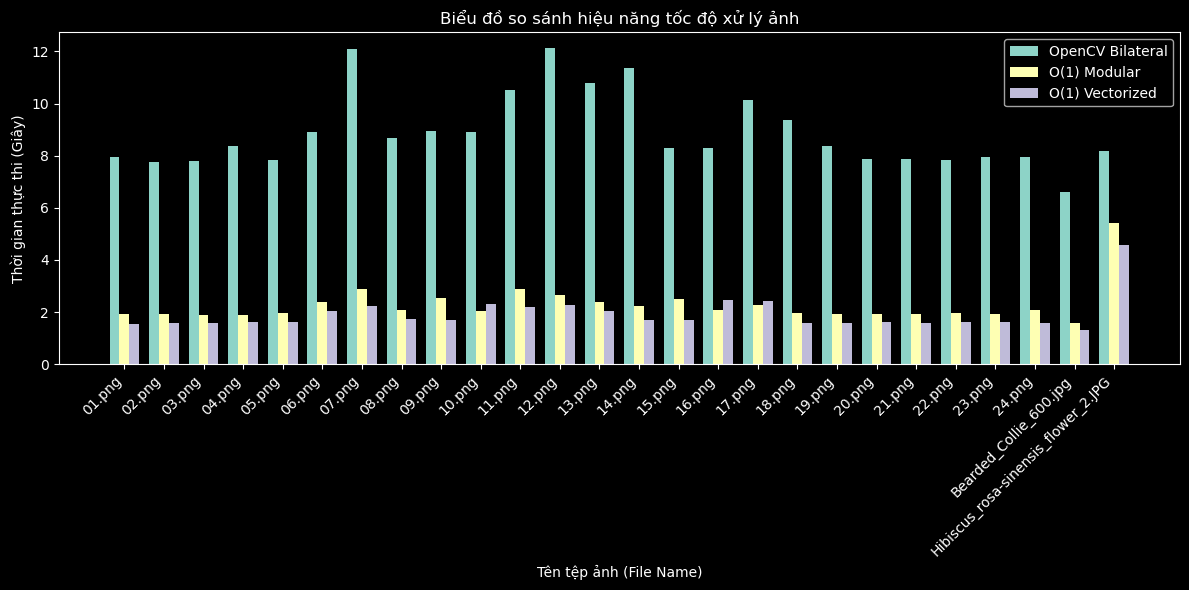

In [10]:
if not df.empty:
    plt.figure(figsize=(12, 6))
    x = np.arange(len(df['Image']))
    width = 0.25

    plt.bar(x - width, df['Time_CV2(s)'], width, label='OpenCV Bilateral')
    plt.bar(x, df['Time_Modular(s)'], width, label='O(1) Modular')
    plt.bar(x + width, df['Time_Vectorized(s)'], width, label='O(1) Vectorized')

    plt.xlabel('Tên tệp ảnh (File Name)')
    plt.ylabel('Thời gian thực thi (Giây)')
    plt.title('Biểu đồ so sánh hiệu năng tốc độ xử lý ảnh')
    plt.xticks(x, df['Image'], rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()

    # Lưu biểu đồ phân tích vào thư mục results2
    plt.savefig(os.path.join(OUTPUT_DIR, 'speed_comparison_chart.png'))
    plt.show()